# Kinetic Profiles from Paired VEST Diagnostics

## Overview

Electron and ion profiles for one slice of VEST shot 48224 at 300 ms, built two
ways from files packaged with VAFT:

- the **stored reference**, `ods_48224_300ms.json`, generated through OMFIT's
  `fluxSurfaces` mapping;
- a **rebuild** from the paired raw diagnostics — the EFIT g-file, the
  Thomson-scattering `.mat` and the ion-Doppler `.mat` — mapped onto the
  equilibrium by VAFT's own flux interpolation.

The two routes disagree slightly by construction, and the page measures the
disagreement rather than asserting it. Everything runs offline.

## Pipeline context

Downstream of Thomson and charge-exchange mapping, upstream of the kinetic EFIT
and of anything that reads `core_profiles` —
`tokamak_power_balance.ipynb` and `confinement_time_scaling.ipynb` both start
from this product.

In [ ]:
import json
import os
from pathlib import Path

# Resolve against the repository root, not the kernel's cwd: Jupyter starts
# in notebooks/, which would otherwise create a nested notebooks/notebooks/.
_repo_root = Path.cwd()
if _repo_root.name == "notebooks":
    _repo_root = _repo_root.parent
OUTPUT_DIR = Path(os.environ.get(
    "VAFT_DOCS_OUTPUT_DIR", _repo_root / "notebooks" / "outputs" / "docs"
))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# Select the rendering backend explicitly. In a Jupyter kernel (Jupyter Lab,
# VS Code) ask for the inline backend rather than relying on ipykernel to
# preset MPLBACKEND, which older releases do not do. With no IPython at all
# (a plain `python` run) fall back to headless Agg -- export MPLBACKEND,
# e.g. MPLBACKEND=macosx, to get windows from a script instead.
try:
    _ipython = get_ipython()
except NameError:
    _ipython = None
if _ipython is None:
    os.environ.setdefault("MPLBACKEND", "Agg")
elif "IPKernelApp" in _ipython.config:
    _ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt
import numpy as np

from vaft.data.resources import data_path

DATA_ROOT = data_path("kineticEfit")
SHOT, TIME_MS = 48224, 300.0

print(f"{'file':34s} {'bytes':>10s}")
for path in sorted(DATA_ROOT.iterdir()):
    print(f"  {path.name:32s} {path.stat().st_size:10d}")

file                                    bytes
  IDS_48224.mat                         10038
  NeTe_48224.mat                         2325
  g048224.00300                        306066
  g048224.00300.chease                4317087
  g048224.00300.kinetic_efit           306066
  ods_48224_300ms.json                2004254


## Route A: the stored reference

The sample the rest of the collection reads. Shot and time come from the file
itself; they are not free parameters here.

In [ ]:
from omas import ODS

reference = ODS()
reference.load(str(DATA_ROOT / "ods_48224_300ms.json"), consistency_check=False)

stored_shot = int(reference["dataset_description.data_entry.pulse"])
stored_time_ms = float(np.asarray(reference["core_profiles.time"], dtype=float)[0]) * 1e3
stored = reference["core_profiles.profiles_1d.0"]

print(f"shot {stored_shot} at {stored_time_ms:g} ms")
print("  IDS:", ", ".join(sorted(reference.keys())))
print("  core_profiles.profiles_1d.0:", ", ".join(sorted(stored.keys())))

shot 48224 at 300 ms
  IDS: charge_exchange, core_profiles, dataset_description, equilibrium, thomson_scattering, wall
  core_profiles.profiles_1d.0: electrons, grid, ion, pressure_thermal, time


## Route B: rebuild from the paired diagnostics

Four steps, each a mapper: the equilibrium from the g-file, the shot identity,
the Thomson profiles, the ion-Doppler profiles, and then the fit that puts them
on the equilibrium's flux grid. `require_thomson=True` because this page plots
electron profiles — an ion-only fit would otherwise fail later, at the first
electron access, rather than here.

In [ ]:
from vaft.code.efit import build_kinetic_core_profiles
from vaft.data import read_geqdsk
from vaft.machine_mapping.charge_exchange import charge_exchange
from vaft.machine_mapping.dataset_description import dataset_description
from vaft.machine_mapping.thomson_scattering import thomson_scattering

geqdsk = read_geqdsk(DATA_ROOT / f"g0{SHOT}.00{int(TIME_MS)}")
rebuilt = geqdsk.to_omas()
dataset_description(
    rebuilt, source=SHOT,
    options={"source_type": "shot", "description": "Paired documentation sample"},
)
thomson_scattering(rebuilt, SHOT, DATA_ROOT / f"NeTe_{SHOT}.mat")
charge_exchange(rebuilt, shotnumber=SHOT, options="ids", mat_file=DATA_ROOT / f"IDS_{SHOT}.mat")
rebuilt = build_kinetic_core_profiles(
    rebuilt, geqdsk, TIME_MS,
    te_mode="polynomial", ne_mode="polynomial",
    ti_mode="polynomial", vtor_mode="polynomial",
    require_thomson=True,
)
rebuilt_profile = rebuilt["core_profiles.profiles_1d.0"]
print("  Thomson channels:", len(rebuilt["thomson_scattering.channel"]))
print("  charge-exchange channels:", len(rebuilt["charge_exchange.channel"]))

<repo>/vaft/data/eqdsk.py:996: RuntimeWarning: q on axis is 8.07, 4.2x above its immediate neighbours (median 1.9); the toroidal flux integral carries that into rho_tor_norm. The profile is used as given -- see issue #317.


[INFO] dropped 2 invalid TS channel(s) at 300.000 ms (non-finite value/sigma or unmapped position)
[INFO] ne at 300.000 ms: order 3 rejected, using order 2 (few/narrow measurement points)
[INFO] dropped 7 invalid CES T_i channel(s) at 300.000 ms
[INFO] dropped 7 invalid CES V_tor channel(s) at 300.000 ms
[UPDATED] core_profile at 300.000 ms (index 0)
  Thomson channels: 7
  charge-exchange channels: 40


## How far apart the two routes are

The stored sample was mapped through OMFIT's `fluxSurfaces`; the rebuild uses
VAFT's own psi interpolation. Same measurements, different mapping, so the
profiles should agree to the level that mapping choice costs — which is the
number worth having, since every downstream page inherits it.

In [ ]:
def profile_of(container, path):
    return np.asarray(container[path], dtype=float)


rho_reference = profile_of(stored, "grid.rho_tor_norm")
rho_rebuilt = profile_of(rebuilt_profile, "grid.rho_tor_norm")

QUANTITIES = (
    ("electrons.temperature", "T_e", "eV"),
    ("electrons.density", "n_e", "m^-3"),
)

print(f"{'quantity':22s} {'reference peak':>16s} {'rebuilt peak':>14s} {'peak diff':>10s} {'RMS diff':>10s}")
comparison = {}
for path, label, unit in QUANTITIES:
    a = profile_of(stored, path)
    b = np.interp(rho_reference, rho_rebuilt, profile_of(rebuilt_profile, path))
    scale = np.max(np.abs(a))
    peak_difference = abs(np.max(b) - np.max(a)) / scale
    rms_difference = float(np.sqrt(np.mean((b - a) ** 2))) / scale
    comparison[label] = {"peak_rel": peak_difference, "rms_rel": rms_difference}
    print(f"{label + ' [' + unit + ']':22s} {np.max(a):16.4g} {np.max(b):14.4g}"
          f" {peak_difference:9.2%} {rms_difference:9.2%}")

quantity                 reference peak   rebuilt peak  peak diff   RMS diff
T_e [eV]                          103.5          104.4     0.86%     5.25%
n_e [m^-3]                    1.017e+19      1.017e+19     0.04%     0.90%


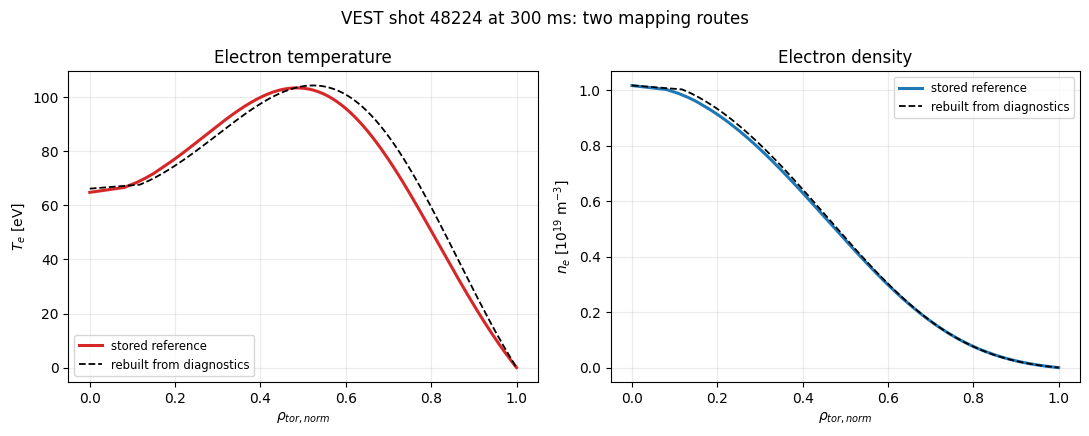

{
  "shot": 48224,
  "time_ms": 300.0,
  "grid_points": 129,
  "route_agreement": {
    "T_e": {
      "peak_rel": 0.00864,
      "rms_rel": 0.05247
    },
    "n_e": {
      "peak_rel": 0.00038,
      "rms_rel": 0.009
    }
  }
}


In [ ]:
PANELS = (
    ("electrons.temperature", 1.0, "$T_e$ [eV]", "Electron temperature", "tab:red"),
    ("electrons.density", 1e19, "$n_e$ [$10^{19}$ m$^{-3}$]", "Electron density", "tab:blue"),
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, (path, scale, ylabel, title, color) in zip(axes, PANELS):
    ax.plot(rho_reference, profile_of(stored, path) / scale, lw=2.2,
            color=color, label="stored reference")
    ax.plot(rho_rebuilt, profile_of(rebuilt_profile, path) / scale, lw=1.3, ls="--",
            color="black", label="rebuilt from diagnostics")
    ax.set(xlabel=r"$\rho_{tor,norm}$", ylabel=ylabel, title=title)
    ax.grid(alpha=0.25)
    ax.legend(fontsize="small")
fig.suptitle(f"VEST shot {SHOT} at {TIME_MS:g} ms: two mapping routes")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "kinetic-profile.png", dpi=180, bbox_inches="tight")
plt.show()

print(json.dumps({
    "shot": SHOT,
    "time_ms": TIME_MS,
    "grid_points": int(rho_reference.size),
    "route_agreement": {
        label: {key: round(value, 5) for key, value in metrics.items()}
        for label, metrics in comparison.items()
    },
}, indent=2))

## Which route to use

The stored sample, for anything that needs the reference numbers: it is what the
other notebooks read, and it does not depend on the mapper's current behaviour.
The rebuild, when the question is about the mapping itself — a new fit mode, a
different flux interpolation, a shot with no stored product. The difference
measured above is the price of the second, and it belongs in the error budget of
anything built on it.